In [1]:
import healpy as hp
import numpy as np
import tensorflow as tf, sys, os
from tensorflow.keras import layers, models, regularizers
import os
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.ndimage import gaussian_filter
tf.keras.backend.clear_session() #clear any previous models

plots_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkyNeuralNets/plots/"
data_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkySimulation/data/simulated_data/"
os.chdir(data_directory)
#os.environ['CUDA_VISIBLE_DEVICES'] = '-1' #disable GPU
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  #suppress TF warnings
print("Current working directory:", os.getcwd())

2025-11-28 20:42:20.605066: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-28 20:42:37.003856: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-28 20:42:41.061818: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/gr/lib64
2025-11-28 20:42:41.061849: I 

Current working directory: /mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkySimulation/data/simulated_data


In [2]:
print("TF:", tf.__version__)
print("Python:", sys.version.split()[0])
print("LD_LIBRARY_PATH:", os.environ.get("LD_LIBRARY_PATH"))

TF: 2.10.1
Python: 3.10.15
LD_LIBRARY_PATH: /mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/gr/lib64


In [3]:
from SkyNeuralNets import read_map
#Read the data
path_lcdm = "./simulated_maps/"
map_temp_data = read_map(path_lcdm + 'cmb_map_0.fits')

#Visualize the map
nside = hp.npix2nside(len(map_temp_data))
#nside = 64
print(f"NSIDE: {nside}")

Filename: ./simulated_maps/cmb_map_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
NSIDE: 256


In [4]:
def read_all_maps(path_lcdm, path_feature, n_maps=100):
    maps = []
    labels = []
    
    #LCDM maps
    for i in range(n_maps):
        map_lcdm = read_map(f"{path_lcdm}cmb_map_{i}.fits")
        maps.append(map_lcdm)
        labels.append(0)  #lcdm
    
    #Feature maps
    for i in range(n_maps):
        map_feature = read_map(f"{path_feature}cmb_map_feature_{i}.fits")
        maps.append(map_feature)
        labels.append(1)  #feature
    
    maps = np.array(maps).astype(np.float32)[..., None]  #Add channel dimension
    labels = np.array(labels).astype(np.int32)
    #print(labels)
    return maps, labels

In [5]:
def map_to_image(hp_map, xsize=256):
    #Validate that map has correct length
    hp_map = np.asarray(hp_map, dtype=np.float64)
    try:
        nside = hp.get_nside(hp_map)
    except Exception as e:
        print("Invalid map shape:", hp_map.shape)
        raise e
    img = hp.cartview(hp_map, xsize=xsize, return_projected_map=True, title="", cbar=False)
    plt.close()
    return img

In [6]:
path_feature = "./simulated_maps/"
x_raw, y_raw = read_all_maps(path_lcdm, path_feature, n_maps=225) #0: lcdm, 1:feature

Filename: ./simulated_maps/cmb_map_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/cmb_map_1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/cmb_map_2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/cmb_map_3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C  

In [7]:
x_raw_new = np.array(x_raw).squeeze()

In [8]:
imgs = np.array([map_to_image(m) for m in x_raw_new])
if imgs.ndim == 3:
    imgs = imgs[..., np.newaxis]  #add channel dimension

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(imgs, y_raw, test_size=0.2, random_state=15)
X_test, X_val, y_test, y_val = train_test_split(imgs, y_raw, test_size=0.2, random_state=15)

In [10]:
np.shape(X_train)

(360, 128, 256, 1)

In [11]:
#Check the class weights to handle imbalance
from sklearn.utils import class_weight
print(f"Training set Class 1 ratio: {y_train.mean():.4f}")
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

Training set Class 1 ratio: 0.4889


In [12]:
from sklearn.decomposition import PCA
def apply_pca_subtraction(X_train, X_val, X_test, y_train, n_components=100):
    """
    Uses PCA to learn the dominant "noise" modes from the Class 0 maps
    and subtracts this learned noise from all maps.
    
    n_components: Number of principal components (noise modes) to learn.
                  You can also use a float (e.g., 0.999) to keep
                  components explaining 99.9% of the variance.
    """
    print(f"Starting PCA Noise Subtraction with n_components={n_components}...")
    
    #1. Get original shape and flatten data
    orig_shape = X_train.shape[1:] #(H, W, 1)
    n_features = np.prod(orig_shape) #H*W*1
    
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_val_flat = X_val.reshape(X_val.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)
    
    #2. Isolate "noise" maps (Class 0) from X_train
    noise_indices = (y_train == 0)
    X_noise_flat = X_train_flat[noise_indices]
    
    if X_noise_flat.shape[0] == 0:
        print("Error: No Class 0 maps found in y_train. Cannot fit PCA.")
        return X_train, X_val, X_test

    print(f"  Fitting PCA on {X_noise_flat.shape[0]} 'noise' maps...")
    
    #3. Fit PCA *only* on the noise maps
    pca = PCA(n_components=n_components, whiten=False)
    pca.fit(X_noise_flat)
    
    print(f"  PCA fitted. Explained variance with {pca.n_components_} components: {np.sum(pca.explained_variance_ratio_):.4f}")
    
    #4. Transform and inverse-transform all maps to get the "noise" part
    print("  Transforming and subtracting noise from all datasets...")
    
    #Project data onto noise basis and reconstruct the noise part
    X_train_noise_part = pca.inverse_transform(pca.transform(X_train_flat))
    X_val_noise_part = pca.inverse_transform(pca.transform(X_val_flat))
    X_test_noise_part = pca.inverse_transform(pca.transform(X_test_flat))
    
    #5. Subtract the noise part to get the signal (residual)
    X_train_signal_part_flat = X_train_flat - X_train_noise_part
    X_val_signal_part_flat = X_val_flat - X_val_noise_part
    X_test_signal_part_flat = X_test_flat - X_test_noise_part
    
    #6. Reshape signal part back to original map shape
    X_train_pca = X_train_signal_part_flat.reshape(X_train.shape).astype(np.float32)
    X_val_pca = X_val_signal_part_flat.reshape(X_val.shape).astype(np.float32)
    X_test_pca = X_test_signal_part_flat.reshape(X_test.shape).astype(np.float32)
    
    print("PCA Noise Subtraction complete.")
    return X_train_pca, X_val_pca, X_test_pca

In [13]:
X_train_pca, X_val_pca, X_test_pca = apply_pca_subtraction(
    X_train, X_val, X_test, y_train, n_components=100)

Starting PCA Noise Subtraction with n_components=100...
  Fitting PCA on 184 'noise' maps...
  PCA fitted. Explained variance with 100 components: 1.0000
  Transforming and subtracting noise from all datasets...
PCA Noise Subtraction complete.


In [22]:
def plot_cartesian_map(img, title="", vclip=3): #vclip determines the color scale window (the contrast)
    """
    Visualize a projected (Cartesian) CMB map, with an optional z-score clipping range.
    """
    img2d = np.squeeze(img)   # remove any trailing channel dimension
    plt.figure(figsize=(6,3))
    im = plt.imshow(img2d, cmap="RdBu_r", origin="lower", vmin=-vclip, vmax=vclip)
    plt.colorbar(im, shrink=0.8, label="Temperature")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [34]:
def visualize_cmb_cleaning(X_data, y_labels, index_to_plot, n_components=100):
    """
    Fits PCA on Class 0 (LCDM) data, cleans a specific map, and visualizes the result.
    
    Args:
        X_data: Your entire dataset of maps (N, H, W) or (N, H, W, 1)
        y_labels: The labels (0 for LCDM, 1 for Feature)
        index_to_plot: The index of the map you want to visualize
        n_components: How many PCA modes to use for the noise model
    """
    
    # 1. Flatten Data for PCA
    # (N, H, W, 1) -> (N, H*W)
    n_samples = X_data.shape[0]
    map_shape = X_data.shape[1:3] # e.g., (100, 100)
    X_flat = X_data.reshape(n_samples, -1)
    
    # 2. Fit PCA on NOISE ONLY (Class 0)
    print("Fitting PCA on background noise (Class 0)...")
    noise_indices = (y_labels == 0)
    X_noise = X_flat[noise_indices]
    
    pca = PCA(n_components=n_components)
    pca.fit(X_noise)
    print(f"Explained variance by {n_components} components: {np.sum(pca.explained_variance_ratio_):.4f}")

    # 3. Process the Target Map
    target_map_flat = X_flat[index_to_plot].reshape(1, -1)
    
    # Reconstruct the "Noise Part"
    # Project onto noise basis -> Inverse transform back
    noise_reconstruction_flat = pca.inverse_transform(pca.transform(target_map_flat))
    
    # Calculate the "Signal Part" (Residual)
    signal_residual_flat = target_map_flat - noise_reconstruction_flat
    
    # 4. Reshape for Plotting
    raw_map = target_map_flat.reshape(map_shape)
    noise_map = noise_reconstruction_flat.reshape(map_shape)
    residual_map = signal_residual_flat.reshape(map_shape)
    
    # 5. Plotting
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Helper to determine scales
    # We lock the scale of Raw and Noise to be the same for fair comparison
    vmin = min(raw_map.min(), noise_map.min())
    vmax = max(raw_map.max(), noise_map.max())
    
    # Plot 1: Raw Input
    im1 = axes[0].imshow(raw_map, cmap='RdBu_r', vmin=vmin, vmax=vmax, origin='lower')
    axes[0].set_title(f"1. Raw Map (Index {index_to_plot})\nClass: {y_labels[index_to_plot]}")
    plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    
    # Plot 2: PCA Noise Model
    im2 = axes[1].imshow(noise_map, cmap='RdBu_r', vmin=vmin, vmax=vmax, origin='lower')
    axes[1].set_title(f"2. PCA Noise Reconstruction\n(What PCA thinks is 'Standard CMB')")
    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Plot 3: The Residual (Signal)
    # IMPORTANT: We let this scale float freely because the signal is tiny!
    im3 = axes[2].imshow(residual_map, cmap='viridis', origin='lower')
    axes[2].set_title(f"3. Residual (Raw - Noise)\n(The Hidden Signal)")
    plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

Fitting PCA on background noise (Class 0)...
Explained variance by 50 components: 1.0000


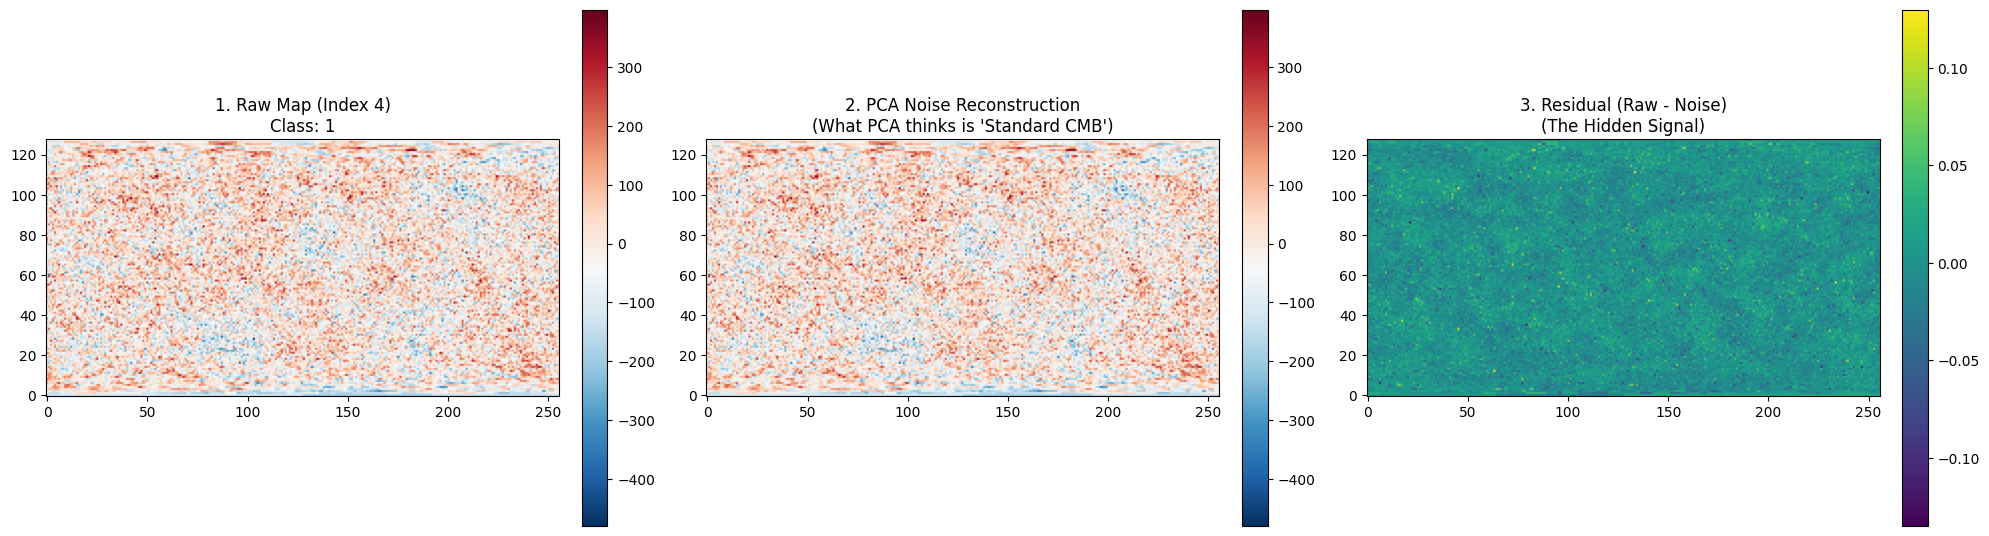

In [35]:
# ==========================================
# EXAMPLE USAGE (Plug your data in here)
# ==========================================

# 1. Load your data here if not already loaded
# X_train = ... 
# y_train = ...

# 2. Pick a map that actually HAS the signal (Class 1)
signal_indices = np.where(y_train == 1)[0]
idx = signal_indices[0]  # Pick the first example with a signal

# 3. Visualize
visualize_cmb_cleaning(X_train, y_train, index_to_plot=idx, n_components=50)

In [48]:
#======== Define Model ========
model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),        

    layers.Conv2D(32, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(), layers.ReLU(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(), layers.ReLU(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(), layers.ReLU(),

    layers.GlobalAveragePooling2D(),             
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
])

In [49]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4, clipnorm=1.0),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)
model.summary(110)

cb = [
  tf.keras.callbacks.EarlyStopping(monitor="val_auc", patience=200, mode="max", restore_best_weights=True),
  tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", factor=0.5, patience=200, mode="max", min_lr=1e-6)
]

Model: "sequential"
______________________________________________________________________________________________________________
 Layer (type)                                    Output Shape                                Param #          
 conv2d (Conv2D)                                 (None, 128, 256, 32)                        288              
                                                                                                              
 batch_normalization (BatchNormalization)        (None, 128, 256, 32)                        128              
                                                                                                              
 re_lu (ReLU)                                    (None, 128, 256, 32)                        0                
                                                                                                              
 max_pooling2d (MaxPooling2D)                    (None, 64, 128, 32)                        

In [50]:
history = model.fit(
    X_train_pca,
    y_train, 
    epochs=500, 
    batch_size=32, 
    validation_data=(X_val_pca, y_val),
    callbacks=cb,
)

Epoch 1/500
12/12 [==============================] - 19s 718ms/step - loss: 0.4214 - accuracy: 0.8389 - auc: 0.9248 - val_loss: 0.7012 - val_accuracy: 0.4556 - val_auc: 0.9184 - lr: 1.0000e-04
Epoch 2/500
12/12 [==============================] - 7s 574ms/step - loss: 0.2385 - accuracy: 0.9417 - auc: 0.9855 - val_loss: 0.7048 - val_accuracy: 0.4556 - val_auc: 0.8980 - lr: 1.0000e-04
Epoch 3/500
12/12 [==============================] - 7s 573ms/step - loss: 0.1670 - accuracy: 0.9694 - auc: 0.9922 - val_loss: 0.7049 - val_accuracy: 0.4556 - val_auc: 0.9184 - lr: 1.0000e-04
Epoch 4/500
12/12 [==============================] - 7s 565ms/step - loss: 0.1337 - accuracy: 0.9750 - auc: 0.9987 - val_loss: 0.6987 - val_accuracy: 0.4556 - val_auc: 1.0000 - lr: 1.0000e-04
Epoch 5/500
12/12 [==============================] - 7s 565ms/step - loss: 0.1244 - accuracy: 0.9806 - auc: 0.9967 - val_loss: 0.6875 - val_accuracy: 0.8556 - val_auc: 1.0000 - lr: 1.0000e-04
Epoch 6/500
12/12 [====================

In [51]:
test_loss, test_acc, test_auc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

12/12 [==============================] - 1s 111ms/step - loss: 13.5867 - accuracy: 0.4889 - auc: 0.5000
Test accuracy: 0.4889


Text(0, 0.5, 'Accuracy')

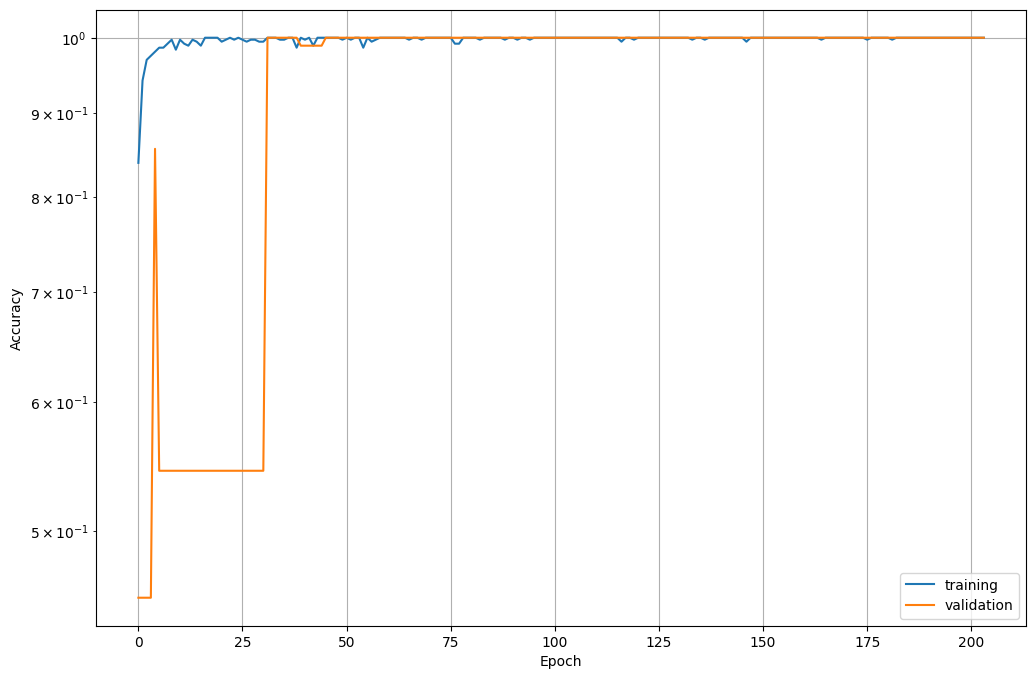

In [52]:
plt.figure(figsize=(12,8))
plt.plot(history.history["accuracy"], label="training")
plt.plot(history.history["val_accuracy"], label="validation")
plt.grid()
plt.yscale("log")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

Text(0, 0.5, 'Loss')

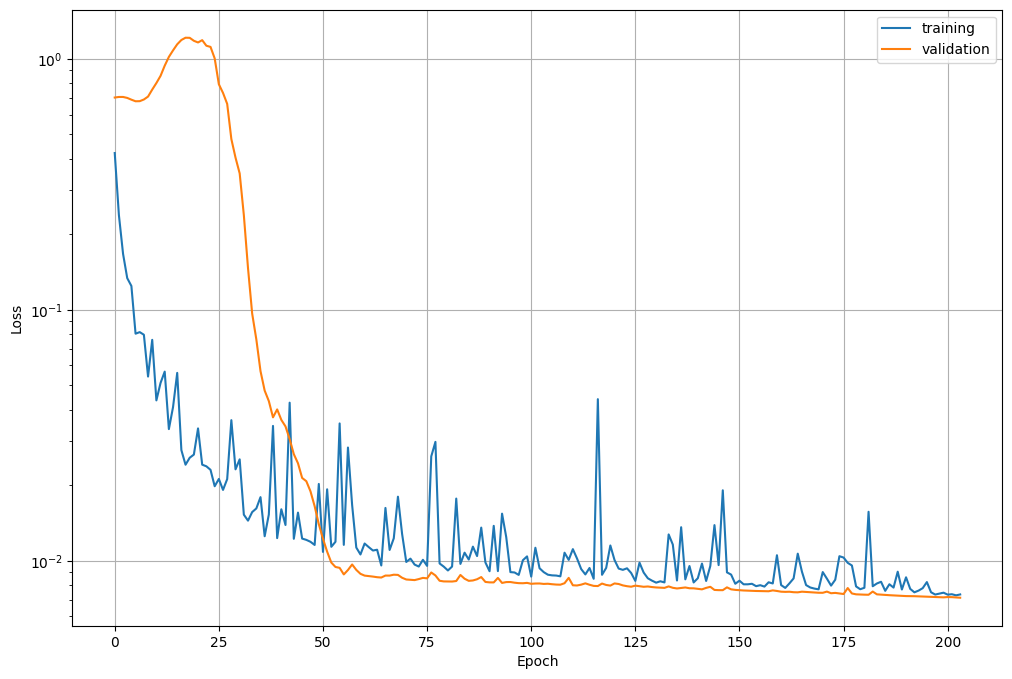

In [53]:
plt.figure(figsize=(12,8))
plt.plot(history.history["loss"], label="training")
plt.plot(history.history["val_loss"], label="validation")
plt.grid()
plt.yscale("log")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")

In [54]:
#sanity check
print(np.mean(X_train_pca), np.std(X_train_pca))   #mean~0, st.dev~1
print(np.mean(X_test_pca),  np.std(X_test_pca))    #should be close to train

6.8170186e-05 0.0072769234
6.8170186e-05 0.0072769234


In [55]:
# Get model probabilities
probs = model.predict(X_test_pca, batch_size=64).ravel()

6/6 [==============================] - 1s 241ms/step


In [56]:
#Check the class balance, do we have a 50/50 split?
print("class balance test:", (y_test==1).mean())

class balance test: 0.4888888888888889


In [57]:
#Let's check the ranges of probabilities, why is the CNN classfiying everything as LCDM?
print("min/max/mean probs:", probs.min(), probs.max(), probs.mean())

min/max/mean probs: 0.46531555 0.48617747 0.46979904


In [58]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

#Find optimal threshold from ROC
fpr, tpr, thr = roc_curve(y_test, probs)
t_opt = thr[np.argmax(tpr - fpr)]
print("AUC:", auc(fpr, tpr), "t*:", t_opt)

#Apply the new threshold to get predictions, Youden's index https://en.wikipedia.org/wiki/Youden%27s_J_statistic
pred = (probs >= t_opt).astype(int)

AUC: 1.0 t*: 0.46707398


In [59]:
#Accuracy
acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)

#Confusion matrix
cm = confusion_matrix(y_test, pred, labels=[0, 1])
print("Confusion matrix:\n", cm)

Accuracy: 1.0
Confusion matrix:
 [[184   0]
 [  0 176]]


In [60]:
#-----------------------------------------------------------------------------------------------------------
#Performance: correct & incorrect  predictions
#-----------------------------------------------------------------------------------------------------------
#True positive: LCDM=0, Feature=1
true_LCDM = []
true_MoG = []
false_LCDM = []
false_MoG = []

for pred, true in zip(pred, y_test):
    if pred==0 and true==0:
        true_LCDM.append(1)
    if pred==1 and true==1:
        true_MoG.append(1)
    if pred==0 and true==1:
        false_LCDM.append(1)
    if pred==1 and true==0:
        false_MoG.append(1)
lenghts=[len(true_LCDM),len(true_MoG),len(false_LCDM),len(false_MoG)]

print('     ','LCDM','FT')
print('True ',len(true_LCDM)/sum(lenghts),len(true_MoG)/sum(lenghts))
print('False',len(false_LCDM)/sum(lenghts),len(false_MoG)/sum(lenghts))
print('--------------')
print("Correct prediction: ",(len(true_LCDM)+len(true_MoG))/sum(lenghts))
print("Wrong prediction  : ",(len(false_LCDM)+len(false_MoG))/sum(lenghts))

      LCDM FT
True  0.5111111111111111 0.4888888888888889
False 0.0 0.0
--------------
Correct prediction:  1.0
Wrong prediction  :  0.0


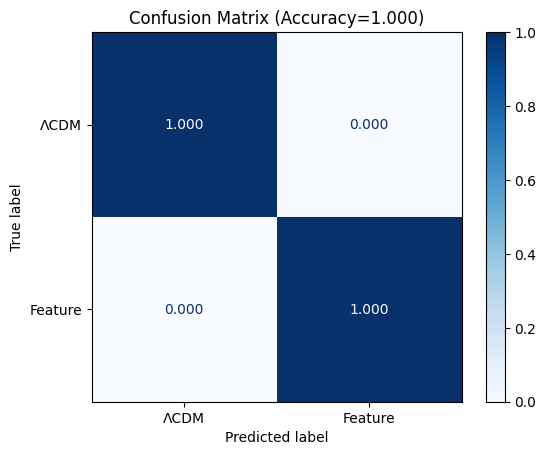

In [61]:
#Plot confusion matrix
cm_prob = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_prob, display_labels=["ΛCDM", "Feature"])
disp.plot(cmap="Blues", values_format='.3f')
plt.title(f"Confusion Matrix (Accuracy={acc:.3f})")
#plt.savefig("/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkyNeuralNets/plots/confusion_matrix.png", dpi=300)
plt.show()

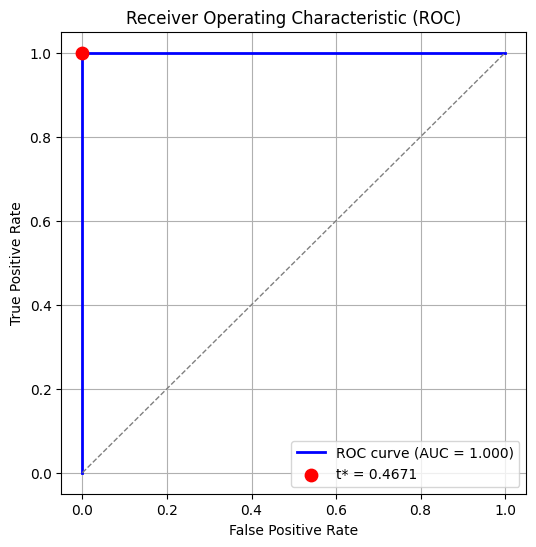

In [62]:
#Plot the ROC curve with Youden index (https://en.wikipedia.org/wiki/Youden%27s_J_statistic#/media/File:ROC_Curve_T1D_Validation,_top5_r2filtered.svg)
from sklearn.metrics import auc
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")

t_star_idx = np.argmax(tpr - fpr)
t_star = thr[t_star_idx]

#Mark t* point
plt.scatter(fpr[t_star_idx], tpr[t_star_idx], color="red", s=80, zorder=5,
            label=f"t* = {t_star:.4f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()